# Indoor Air Quality Prediction using LSTM

This notebook implements a Long Short-Term Memory (LSTM) network to predict Air Quality based on sensor data from `IAQ Baqubah Teaching Hospital .csv`.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [15]:
file_path = "cleaned_dataset.csv"
df = pd.read_csv(file_path)

# Convert Timestamp
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts')
df.set_index('ts', inplace=True)


df = df.ffill().bfill()
df.head()

,CO2,TVOC,PM10,PM2.5,CO,Air Quality,LDR,O3,Temp,Hum
ts,,,,,,,,,,
2024-05-22 12:10:00,422.250000,15.250000,5.215000,0.290000,358.750000,41.750000,962.000000,521.750000,26.250000,41.675000
2024-05-22 12:15:00,422.333333,17.250000,5.762500,0.279583,360.250000,40.916667,962.000000,524.208333,26.116667,41.658333
2024-05-22 12:20:00,421.790476,18.395238,6.052429,0.286976,359.404762,40.785714,960.847619,524.788095,26.061905,41.807143
2024-05-22 12:25:00,421.247619,19.540476,6.342357,0.294369,358.559524,40.654762,959.695238,525.367857,26.007143,41.955952
2024-05-22 12:30:00,420.704762,20.685714,6.632286,0.301762,357.714286,40.523810,958.542857,525.947619,25.952381,42.104762


## 2. Preprocessing for LSTM

In [16]:
# Select features and target
features = ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR']
target = 'PM2.5'

data = df[features + [target]].values

# Split data FIRST to avoid data leakage
split_idx = int(len(data) * 0.8)
train_data_raw = data[:split_idx]
test_data_raw = data[split_idx:]

# Scale data (Fit on Train, Transform Test)
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data_raw)
test_data = scaler.transform(test_data_raw)

# Create separate scaler for target (for inverse transform later)
scaler_y = MinMaxScaler()
scaler_y.fit(train_data_raw[:, -1].reshape(-1, 1))

# Create sequences
n_input = 10 # Number of past time steps to look back
n_features = train_data.shape[1]
batch_size = 32

train_generator = TimeseriesGenerator(train_data, train_data[:, -1], length=n_input, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_data, test_data[:, -1], length=n_input, batch_size=batch_size)

## 3. Build LSTM Model

In [17]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_input, n_features)))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,251 (47.86 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

In [18]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

Epoch 1/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0058 - val_loss: 0.0072
Epoch 2/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 0.0033 - val_loss: 0.0073
Epoch 3/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 0.0028 - val_loss: 0.0055
Epoch 4/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 0.0027 - val_loss: 0.0053
Epoch 5/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0026 - val_loss: 0.0056
Epoch 6/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.0025 - val_loss: 0.0053
Epoch 7/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0025 - val_loss: 0.0059
Epoch 8/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.0024 - val_loss: 0.0056
Epoch 9/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0024 - val_loss: 0.0050
Epoch 10/10
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.0024 - val_loss: 0.0051


## 5. Evaluation

410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Performance Metrics:
RMSE: 18.3300403582651
MSE: 335.99037953562737
MAE: 13.96282784620687
R2 Score: 0.739866625553439
MAPE: 0.14425482610269413


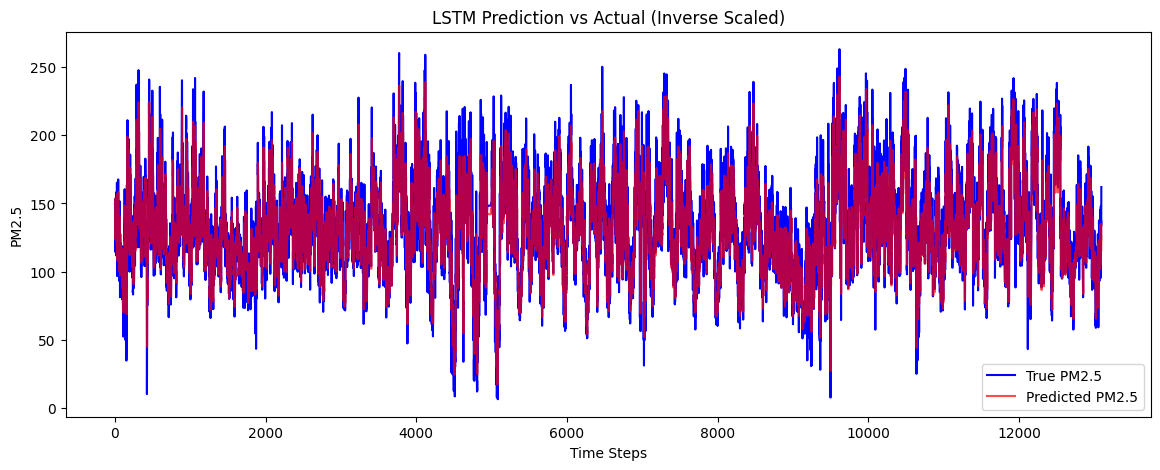

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# Make predictions
predictions = model.predict(test_generator)

# Inverse transform predictions
predictions_inv = scaler_y.inverse_transform(predictions)

# Get true values
# The test_generator starts at index n_input of the test_data
y_true = test_data[n_input:, -1]
y_true_inv = scaler_y.inverse_transform(y_true.reshape(-1, 1))

# Calculate metrics
mse = mean_squared_error(y_true_inv, predictions_inv)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true_inv, predictions_inv)
r2 = r2_score(y_true_inv, predictions_inv)
mean_pm2_5 = df['PM2.5'].mean()
mape = mae/mean_pm2_5

print("Performance Metrics:")
print(f"RMSE: {rmse}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")
print(f"MAPE: {mape}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_true_inv, label='True PM2.5', color='blue')
plt.plot(predictions_inv, label='Predicted PM2.5', color='red', alpha=0.7)
plt.title('LSTM Prediction vs Actual (Inverse Scaled)')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


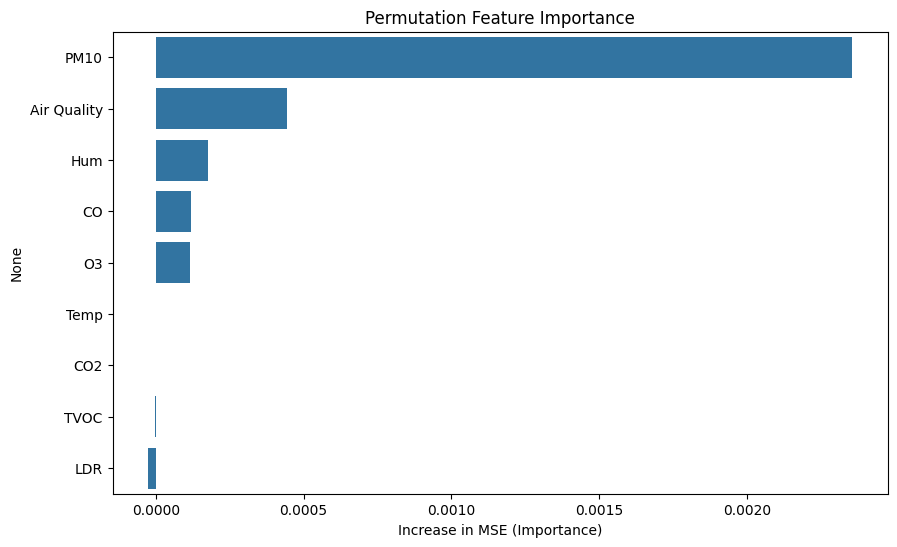

In [21]:
# Permutation Feature Importance (Perturbation on Test Data)
def calculate_permutation_importance(model, data, n_input, batch_size, features):
    # data is the scaled test_data array
    baseline_gen = TimeseriesGenerator(data, data[:, -1], length=n_input, batch_size=batch_size)
    baseline_pred = model.predict(baseline_gen)
    
    # Align targets
    baseline_targets = baseline_gen.targets[n_input:]
    # Ensure lengths match exactly (sometimes generator drops last batch if not divisible? No, TimeseriesGenerator handles it)
    min_len = min(len(baseline_targets), len(baseline_pred))
    baseline_targets = baseline_targets[:min_len]
    baseline_pred = baseline_pred[:min_len]
    
    baseline_mse = mean_squared_error(baseline_targets, baseline_pred)
    
    importances = {}
    
    for i, feature in enumerate(features):
        # Create a copy and shuffle the feature column
        data_copy = data.copy()
        np.random.shuffle(data_copy[:, i])
        
        # Create generator with shuffled feature
        shuffled_gen = TimeseriesGenerator(data_copy, data_copy[:, -1], length=n_input, batch_size=batch_size)
        shuffled_pred = model.predict(shuffled_gen)
        
        # Align targets for shuffled data
        shuffled_targets = shuffled_gen.targets[n_input:]
        shuffled_targets = shuffled_targets[:min_len]
        shuffled_pred = shuffled_pred[:min_len]
        
        shuffled_mse = mean_squared_error(shuffled_targets, shuffled_pred)
        
        # Importance = Increase in MSE
        importances[feature] = shuffled_mse - baseline_mse
    
    return pd.Series(importances).sort_values(ascending=False)

# Calculate and Plot
importance = calculate_permutation_importance(model, test_data, n_input, batch_size, features)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index)
plt.title(f'Permutation Feature Importance')
plt.xlabel('Increase in MSE (Importance)')
plt.show()